In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [3]:
# тензор + нормализация
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# скачиваем датасеты (обучающий и тестовый)
trainset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# загрузчики батчей
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

100%|██████████| 26.4M/26.4M [00:02<00:00, 13.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 205kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.80MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 23.5MB/s]


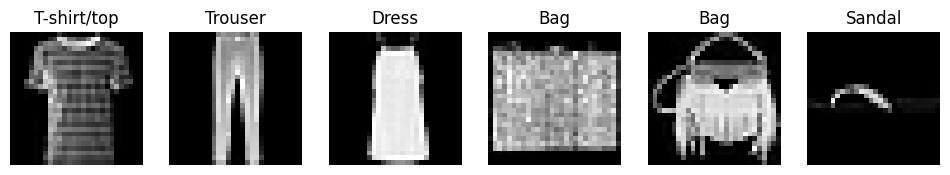

In [4]:

classes = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Берём один батч из trainloader
dataiter = iter(trainloader)
images, labels = next(dataiter)

# Показываем первые 6 картинок для примера
fig, axes = plt.subplots(1, 6, figsize=(12, 3))
for i, ax in enumerate(axes):
    ax.imshow(images[i].squeeze(), cmap='gray')
    ax.set_title(classes[labels[i]])
    ax.axis('off')
plt.show()


In [5]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = Net()
print(model)

Net(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.25, inplace=False)
)


In [6]:
def train_model(model, trainloader, criterion, optimizer, epochs=5):
    train_losses = []  # сохранение loss каждой эпохи
    train_accuracies = []  # accuracy к-й эпохи
    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0
        for images, labels in trainloader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(trainloader)
        epoch_acc = 100 * correct / total
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)
        print(f'Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%')
    return train_losses, train_accuracies

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

losses, accs = train_model(model, trainloader, criterion, optimizer, epochs=5)

Epoch 1/5 - Loss: 0.4770, Accuracy: 82.89%
Epoch 2/5 - Loss: 0.3055, Accuracy: 88.96%
Epoch 3/5 - Loss: 0.2557, Accuracy: 90.78%
Epoch 4/5 - Loss: 0.2277, Accuracy: 91.59%
Epoch 5/5 - Loss: 0.2041, Accuracy: 92.42%


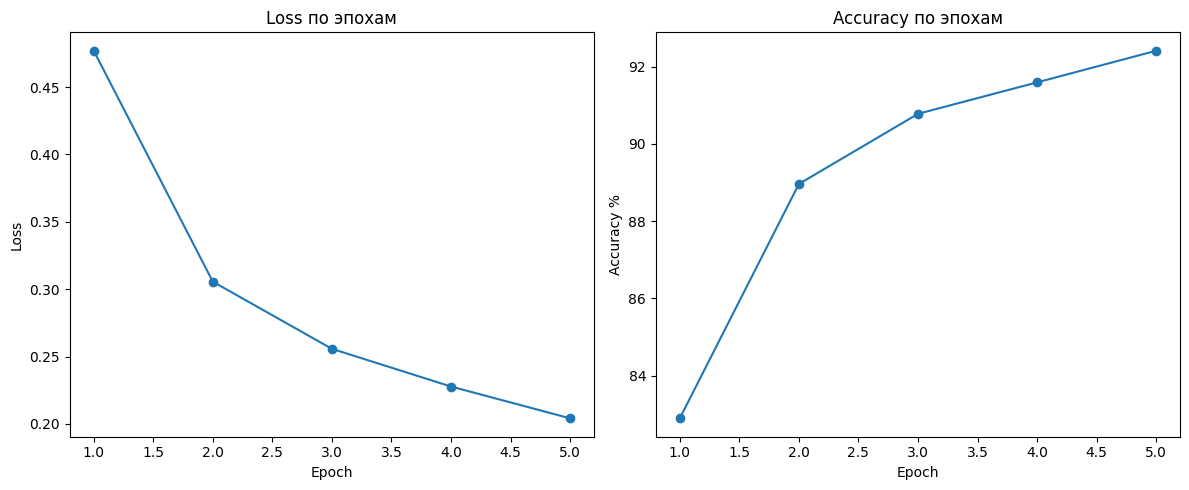

In [8]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(losses)+1), losses, marker='o')
plt.title('Loss по эпохам')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(1, 2, 2)
plt.plot(range(1, len(accs)+1), accs, marker='o')
plt.title('Accuracy по эпохам')
plt.xlabel('Epoch')
plt.ylabel('Accuracy %')

plt.tight_layout()
plt.show()

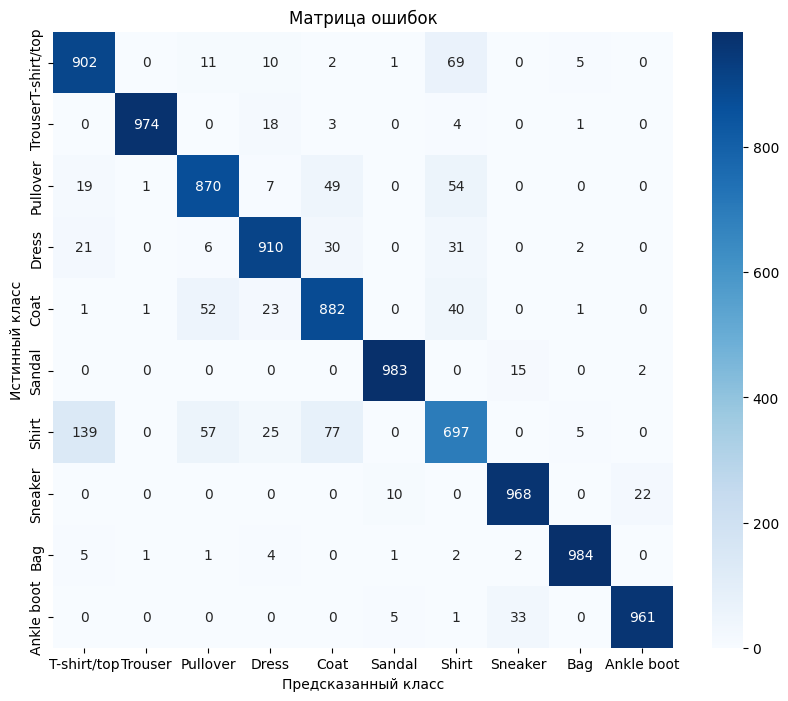

In [9]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in testloader:
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок')
plt.show()

In [10]:
# Сохраняем веса модели в файл
torch.save(model.state_dict(), 'fashion_mnist_cnn.pth')
print("Модель сохранена в fashion_mnist_cnn.pth")

Модель сохранена в fashion_mnist_cnn.pth


In [11]:
correct = 0
total = 0
model.eval()  # режим оценки
with torch.no_grad():
    for images, labels in testloader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Test Accuracy: {100 * correct / total:.2f}%')

Test Accuracy: 91.31%


In [12]:
# Создаём новую модель той же архитектуры
model_loaded = Net()

# Загружаем в неё сохранённые веса
model_loaded.load_state_dict(torch.load('fashion_mnist_cnn.pth'))
model_loaded.eval()
print("Модель загружена и готова к предсказаниям")

# Проверим на одном батче
dataiter = iter(testloader)
images, labels = next(dataiter)
outputs = model_loaded(images)
_, predicted = torch.max(outputs, 1)
print("Пример предсказаний:", [classes[p] for p in predicted[:5]])
print("Истинные классы:   ", [classes[l] for l in labels[:5]])

Модель загружена и готова к предсказаниям
Пример предсказаний: ['Ankle boot', 'Pullover', 'Trouser', 'Trouser', 'Shirt']
Истинные классы:    ['Ankle boot', 'Pullover', 'Trouser', 'Trouser', 'Shirt']
